In [1]:
import os 
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from image_stitching import models
import utils.plot_utils as pu
import utils.file_utils as fu
%load_ext autoreload
%autoreload 2

# View Connectivity of Images

In [2]:
Pano = models.Panorama("/home/schmidtg/coding_projetcs/local-image-features-apps/src/image_stitching/datasets/example-data/CMU1")
_ = Pano.detect()
_ = Pano.match_all_images()

In [4]:
Pano.matching_df[0:15]

,Descriptor,ImgId,Matched_Ids,Distances,Matched_ImgIds
0,"[39, 239, 192, 187, 206, 161, 182, 207, 30, 25...",0,"[4522, 4797, 4344, 4392, 3922]","[53.0, 67.0, 70.0, 71.0, 72.0]","[9, 9, 8, 8, 7]"
1,"[218, 78, 238, 94, 27, 240, 95, 134, 181, 71, ...",0,"[4527, 2995, 4746, 4804, 4781]","[41.0, 72.0, 72.0, 73.0, 74.0]","[9, 5, 9, 9, 9]"
2,"[224, 187, 221, 20, 232, 8, 85, 159, 234, 213,...",0,"[5612, 6122, 2204]","[73.0, 77.0, 78.0, 79.0, 79.0]","[11, 12, 4]"
3,"[209, 115, 19, 102, 50, 142, 67, 240, 57, 136,...",0,"[1541, 852, 5737, 786]","[42.0, 57.0, 61.0, 61.0, 62.0]","[3, 1, 11, 1]"
4,"[34, 207, 107, 77, 114, 131, 191, 246, 53, 12,...",0,"[739, 911, 4746, 2125, 2621]","[63.0, 66.0, 68.0, 69.0, 71.0]","[1, 1, 9, 4, 5]"
5,"[55, 102, 195, 37, 226, 114, 143, 74, 33, 230,...",0,"[1926, 4821, 1934, 4282, 4993]","[63.0, 74.0, 82.0, 83.0, 83.0]","[3, 9, 3, 8, 9]"
6,"[210, 188, 62, 190, 27, 196, 17, 237, 191, 17,...",0,"[1634, 5265, 968, 1523]","[48.0, 52.0, 58.0, 60.0, 62.0]","[3, 10, 1, 3]"
7,"[99, 17, 253, 95, 172, 235, 181, 9, 238, 67, 2...",0,"[3664, 1402, 1403, 2601]","[73.0, 77.0, 84.0, 84.0, 84.0]","[7, 2, 2, 5]"
8,"[81, 241, 25, 103, 176, 12, 47, 188, 42, 104, ...",0,"[2581, 6245]","[60.0, 63.0, 64.0, 66.0, 66.0]","[5, 12]"
9,"[67, 223, 21, 191, 160, 172, 44, 183, 60, 91, ...",0,"[4915, 5729, 1438, 2757]","[48.0, 55.0, 58.0, 58.0, 59.0]","[9, 11, 2, 5]"


In [5]:
Pano.print_matching_stats()

0 | medium08.jpg
	3 | medium09.jpg | 79.0 | 0.158
	9 | medium07.jpg | 51.0 | 0.102
	1 | medium11.jpg | 44.0 | 0.088
	8 | medium12.jpg | 42.0 | 0.084
	11 | medium00.jpg | 40.0 | 0.08
	5 | medium05.jpg | 37.0 | 0.074
	2 | medium04.jpg | 34.0 | 0.068
	6 | medium10.jpg | 29.0 | 0.058
	7 | medium02.jpg | 29.0 | 0.058
	12 | medium01.jpg | 24.0 | 0.048
	4 | medium03.jpg | 22.0 | 0.044
	10 | medium06.jpg | 13.0 | 0.026

1 | medium11.jpg
	6 | medium10.jpg | 212.0 | 0.424
	8 | medium12.jpg | 123.0 | 0.246
	11 | medium00.jpg | 60.0 | 0.12
	4 | medium03.jpg | 42.0 | 0.084
	12 | medium01.jpg | 42.0 | 0.084
	5 | medium05.jpg | 28.0 | 0.056
	2 | medium04.jpg | 27.0 | 0.054
	7 | medium02.jpg | 27.0 | 0.054
	9 | medium07.jpg | 25.0 | 0.05
	3 | medium09.jpg | 23.0 | 0.046
	10 | medium06.jpg | 22.0 | 0.044
	0 | medium08.jpg | 20.0 | 0.04

2 | medium04.jpg
	5 | medium05.jpg | 122.0 | 0.244
	4 | medium03.jpg | 70.0 | 0.14
	3 | medium09.jpg | 39.0 | 0.078
	0 | medium08.jpg | 36.0 | 0.072
	7 | medium02.jpg |

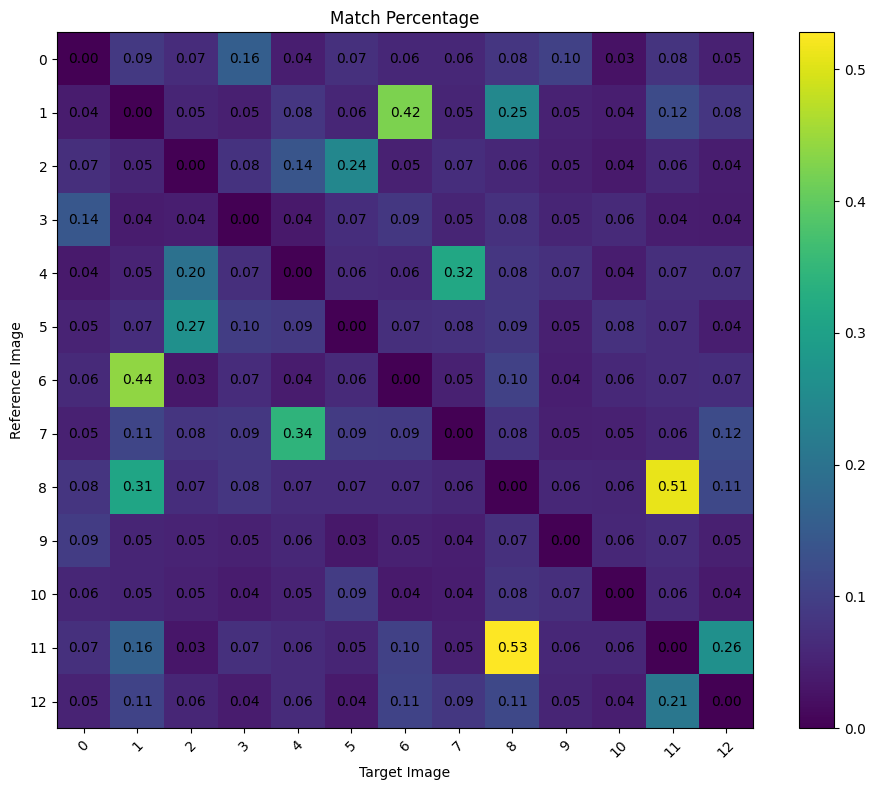

In [3]:
M_ratio = Pano.match_ratio_matrix()
pu.plot_connectivity_matrix(M_ratio)

Is fully connected:  True
Best base node:  8


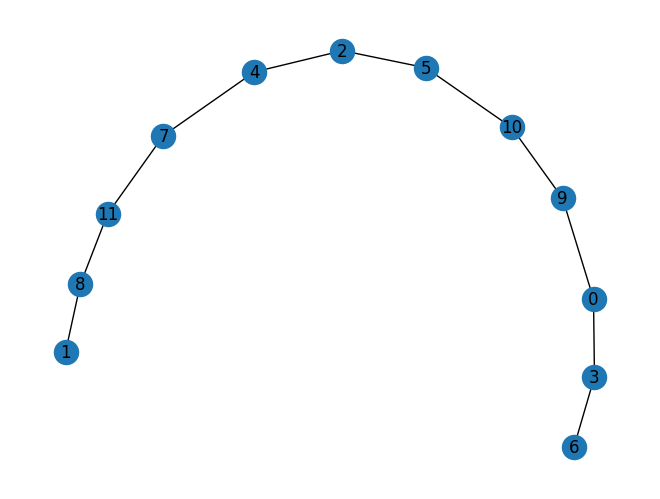

In [ ]:
PG = models.PanoramaGraph(match_threshold=0.08)
PG.initialize_graph(M_ratio)
print("Is fully connected: ", PG.fully_connected)
print("Best base node: ", PG.base_node)
pu.plot_panorama_graph(PG)

# What Ratios Get Fully Connected Graphs

1. View if Fully Connected After Initializing Graph (connecting images based on likely connections)
2. View if Fully Connected After establishing inliers with homographies

In [ ]:
dirs = fu.get_folders("/home/schmidtg/coding_projetcs/local-image-features-apps/src/image_stitching/datasets/example-data")

for dir in dirs:
    basename = os.path.basename(dir)
    Pano = models.Panorama(dir)
    _ = Pano.detect()
    _ = Pano.match_all_images()
    M = Pano.match_ratio_matrix()
    PG = models.PanoramaGraph(0.1)
    PG.initialize_graph(M)
    print(f"{basename}: fully connected = {PG.fully_connected}")

CMU2: fully connected = True
myself: fully connected = True
CMU0: fully connected = True
CMU1: fully connected = True
NSH: fully connected = True
zijing: fully connected = True
flower: fully connected = True
uav: fully connected = True


In [ ]:
dirs = fu.get_folders("/home/schmidtg/coding_projetcs/local-image-features-apps/src/image_stitching/datasets/example-data")

for dir in dirs:
    basename = os.path.basename(dir)
    Pano = models.Panorama(dir)
    Pano.inlier_threshold = 0.15
    Pano.connection_threshold = 0.25
    Pano.generate_graph()
    PG = Pano.PG
    print(f"{basename}: fully connected = {PG.fully_connected}")

uav: fully connected = True
uav: fully connected = True
uav: fully connected = True
uav: fully connected = True
uav: fully connected = True
uav: fully connected = True
uav: fully connected = True
uav: fully connected = True


# View Stages of the Panorama Graph

1. After establishing finding pssoible connections (PG.initialize_graph(M))
2. After estabsling true connections with inliers

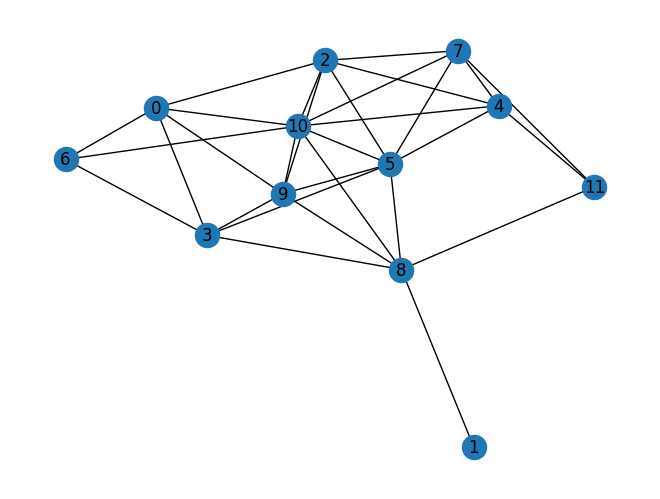

True

In [8]:
Pano = models.Panorama("/home/schmidtg/coding_projetcs/local-image-features-apps/src/image_stitching/datasets/example-data/zijing")
_ = Pano.detect()
_ = Pano.match_all_images()
M = Pano.match_ratio_matrix()
PG = models.PanoramaGraph(0.1)
PG.initialize_graph(M)
pu.plot_panorama_graph(PG)
PG.fully_connected

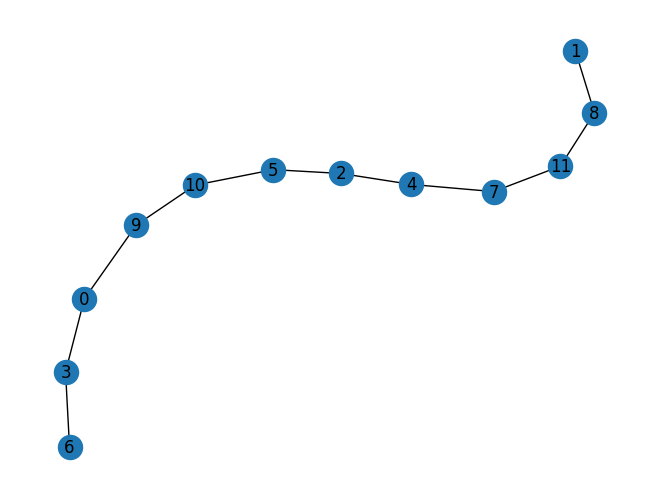

True

In [9]:
Pano.generate_graph()
pu.plot_panorama_graph(Pano.PG)
Pano.PG.fully_connected